# 07 — Uncertainty: MC-Dropout + Split Conformal Prediction

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))
import numpy as np, torch, matplotlib.pyplot as plt
from src.data import load_processed
from src.models.mlp import MLPRegressor
from src.uncertainty import mc_dropout_predict, split_conformal_intervals, coverage
from src.config import MODELS_DIR, FIGURES_DIR
from src.train import predict_torch

In [2]:
X_val, y_val = load_processed('val')
X_test, y_test = load_processed('test')
model = MLPRegressor(X_val.shape[1])
model.load_state_dict(torch.load(MODELS_DIR / 'mlp.pt', map_location='cpu'))

<All keys matched successfully>

## MC-Dropout (50 forward passes)

mean std = 0.3139583


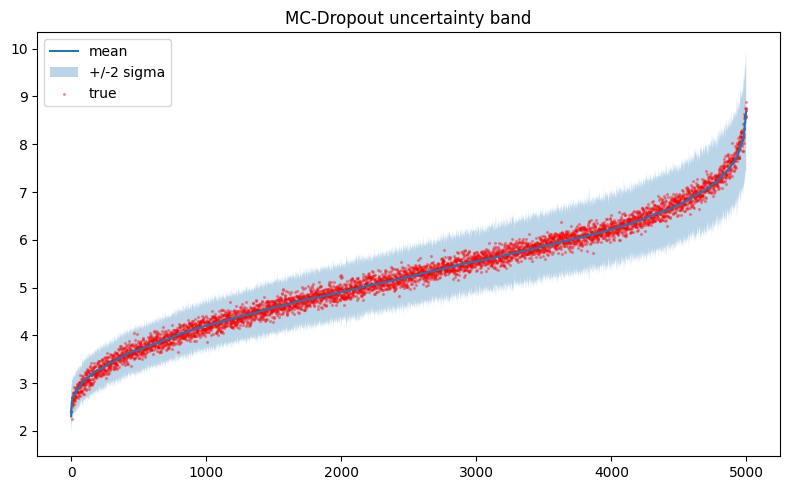

In [3]:
mean_pred, std_pred = mc_dropout_predict(model, X_test[:5000], n_samples=50)
print('mean std =', std_pred.mean())
fig, ax = plt.subplots(figsize=(8,5))
order = np.argsort(mean_pred)
ax.plot(mean_pred[order], label='mean')
ax.fill_between(np.arange(len(order)), mean_pred[order]-2*std_pred[order], mean_pred[order]+2*std_pred[order], alpha=0.3, label='+/-2 sigma')
ax.scatter(np.arange(len(order)), y_test[:5000][order], s=2, alpha=0.3, color='red', label='true')
ax.legend(); ax.set_title('MC-Dropout uncertainty band')
plt.tight_layout(); plt.savefig(FIGURES_DIR / '07_mc_dropout.png', dpi=120); plt.show()

## Split Conformal Prediction (95% interval)

In [4]:
calib_pred = predict_torch(model, X_val)
test_pred = predict_torch(model, X_test)
lo, hi, q = split_conformal_intervals(y_val, calib_pred, test_pred, alpha=0.05)
print(f'q = {q:.4f}, coverage = {coverage(y_test, lo, hi):.3f}')

q = 0.2157, coverage = 0.950


In [5]:
import numpy as np, joblib
joblib.dump({'q': float(q), 'alpha': 0.05}, MODELS_DIR / 'conformal_q.joblib')

['D:\\ZE5 PORTOFOLIO DS\\Q-Factor Prediction in Optical Communication Systems\\models\\conformal_q.joblib']